# Lab Task:

####  Model: Build and train a custom CNN with the following structure:

Conv2D(64 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(128 filters, (3×3), ReLU) → BatchNormalization → MaxPooling2D(2×2)

Conv2D(256 filters, (3×3), ReLU) → Dropout(0.3) → MaxPooling2D(2×2)

Flatten → Dense(256, ReLU) → Dropout(0.5) → Dense(1, Sigmoid)

#### Dataset: Use only two classes:

from the last lab tasks

#### Compile with: binary_crossentropy loss and adam optimizer.

#### Train and evaluate the model.

In [1]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

In [6]:
checkpoints = r'C:\Users\Muhammad Mubien\Documents\python env 3.12\Lab 07\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

In [7]:
train_dir = r'C:\Users\Muhammad Mubien\Documents\python env 3.12\Lab 07\ComputerVision\train'
validation_dir = r'C:\Users\Muhammad Mubien\Documents\python env 3.12\Lab 07\ComputerVision\validation'
test_dir = r'C:\Users\Muhammad Mubien\Documents\python env 3.12\Lab 07\ComputerVision\test'

In [8]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4,activation='softmax'))

In [9]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
model.compile(loss='categorical_crossentropy', optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

In [11]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


In [12]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

In [17]:
step_size_train = train_generator.n//train_generator.batch_size

model_history = model.fit(train_generator,
                    validation_data =validation_generator,
                   steps_per_epoch=step_size_train,
                   epochs=2,
                    callbacks=callbacks)

Epoch 1/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - acc: 0.9303 - loss: 0.1670
Epoch 1: val_loss did not improve from 0.23056
50/50 ━━━━━━━━━━━━━━━━━━━━ 147s 3s/step - acc: 0.9301 - loss: 0.1673 - val_acc: 0.8651 - val_loss: 0.2835
Epoch 2/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - acc: 0.9276 - loss: 0.1790
Epoch 2: val_loss improved from 0.23056 to 0.22610, saving model to C:\Users\Muhammad Mubien\Documents\python env 3.12\Lab 07\E1-cp-0002-loss0.23.h5


50/50 ━━━━━━━━━━━━━━━━━━━━ 145s 3s/step - acc: 0.9276 - loss: 0.1789 - val_acc: 0.8889 - val_loss: 0.2261


In [19]:
model_history.history

{'acc': [0.9225000143051147, 0.9281250238418579],
 'loss': [0.1864796131849289, 0.1695108562707901],
 'val_acc': [0.8650793433189392, 0.8888888955116272],
 'val_loss': [0.2834590673446655, 0.2261013239622116]}

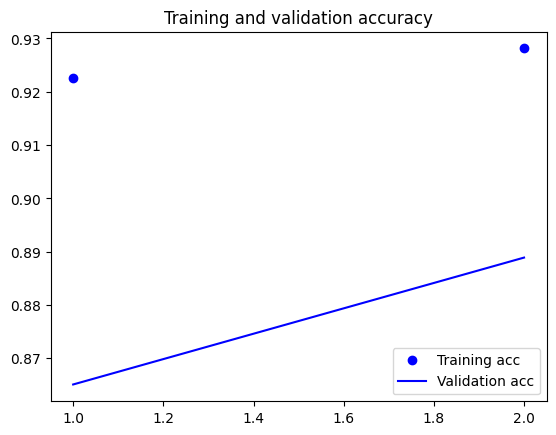

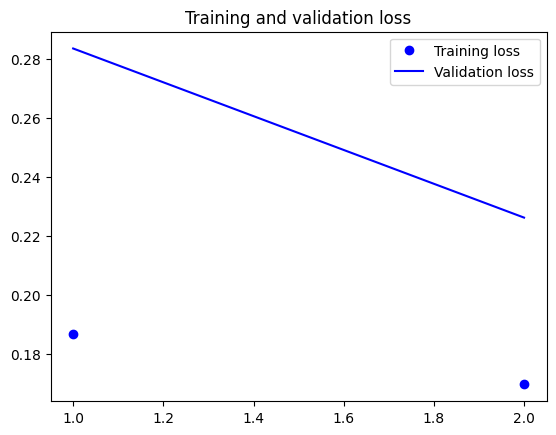

<Figure size 640x480 with 0 Axes>

In [22]:
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
plt.savefig(r'C:\Users\Muhammad Mubien\Documents\python env 3.12\Lab 08\validation accuracy figure.jpeg')

In [23]:
model.save(r'C:\Users\Muhammad Mubien\Documents\python env 3.12\Lab 08\E1-cp-0012-loss0.21.h5')

Found 200 images belonging to 4 classes.


e:\anaconda\envs\dsp\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 518ms/step


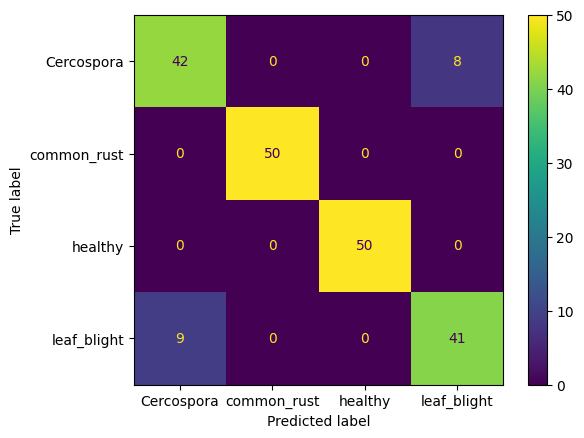

In [24]:
#model = load_model(r'C:\Users\Muhammad Mubien\Documents\python env 3.12\Lab 07\model_lab11.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Muhammad Mubien\Documents\python env 3.12\Lab 07\confusion_matrics.jpg')

In [25]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.82      0.84      0.83        50
 common_rust       1.00      1.00      1.00        50
     healthy       1.00      1.00      1.00        50
 leaf_blight       0.84      0.82      0.83        50

    accuracy                           0.92       200
   macro avg       0.92      0.91      0.91       200
weighted avg       0.92      0.92      0.91       200



In [4]:
!pip install tensorflow


   ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/331.7 MB ? eta -:--:--
   ---------------------------------------- 0.5/331.7 MB 342.2 kB/s eta 0:16:08
   ---------------------------------------- 0.5/331.7 MB 342.2 kB/s eta 0:16:08
   ---------------------------------------- 0.5/331.7 MB 342.2 kB/s eta 0:16:08
   ---------------------------------------- 0.8/331.7 MB 419.4 kB/s eta 0:13:09
   ---------------------------------------- 1.0/331.7 MB 503.2 kB/s eta 0:10:58
   ---------------------------------------- 1.0/331.7 MB 503.2 kB/s eta 0:10:58
   ---------------------------------------- 1.0/331.7 MB 503.2 kB/s eta 0:10:58
   ---------------------------------------- 1.3/331.7 MB 479.2 kB/s eta 0:11:30
   --


   ----------- --------------------------- 93.6/331.7 MB 363.1 kB/s eta 0:10:56
   ----------- --------------------------- 93.8/331.7 MB 366.5 kB/s eta 0:10:49
   ----------- --------------------------- 93.8/331.7 MB 366.5 kB/s eta 0:10:49
   ----------- --------------------------- 94.1/331.7 MB 370.7 kB/s eta 0:10:41
   ----------- --------------------------- 94.1/331.7 MB 370.7 kB/s eta 0:10:41
   ----------- --------------------------- 94.1/331.7 MB 370.7 kB/s eta 0:10:41
   ----------- --------------------------- 94.4/331.7 MB 364.9 kB/s eta 0:10:51
   ----------- --------------------------- 94.4/331.7 MB 364.9 kB/s eta 0:10:51
   ----------- --------------------------- 94.4/331.7 MB 364.9 kB/s eta 0:10:51
   ----------- --------------------------- 94.6/331.7 MB 358.6 kB/s eta 0:11:01
   ----------- --------------------------- 94.6/331.7 MB 358.6 kB/s eta 0:11:01
   ----------- --------------------------- 94.9/331.7 MB 360.1 kB/s eta 0:10:58
   ----------- ------------------------